In [ ]:
#DATA CITATION
# Atmospheric Radiation Measurement (ARM) user facility. 2021. X-Band Scanning ARM Cloud Radar (XSACRCFRQC), 2022-06-09 to 2022-07-02, ARM Mobile Facility (HOU) Houston, TX; AMF1 (main site for TRACER) (M1). Compiled by Y. Feng, A. Matthews, E. Schuman, K. Johnson, I. Lindenmaier, V. Castro and T. Wendler. ARM Data Center. Data set accessed 2025-11-05 at http://dx.doi.org/10.5439/2001296.

#Globus Download Link
# https://urldefense.com/v3/__https://app.globus.org/file-manager?origin_id=ba87aabe-30f6-433d-b4a5-19434c595e0f&origin_path=*rosemana1*261781*__;Ly8v!!PvDODwlR4mBZyAb0!REKAOzHJNvJk50CY5Pjl135CV83BhArwtdyMDuBM-28KqreBug8Xb5Mc3MLgy_p9PUiWe2uVXq-EfUtLcGdH5w$

In [ ]:
#DATA CITATION
# Atmospheric Radiation Measurement (ARM) user facility. 2021. Ka-Band Scanning ARM Cloud Radar (KASACRCFRQC), 2022-06-08 to 2022-07-02, ARM Mobile Facility (HOU) Houston, TX; AMF1 (main site for TRACER) (M1). Compiled by I. Lindenmaier, K. Johnson, D. Nelson, A. Matthews, T. Wendler, V. Melo de Castro, M. Rocque and Y. Feng. ARM Data Center. Data set accessed 2025-11-05 at http://dx.doi.org/10.5439/1877338.

# https://armgov.svcs.arm.gov/capabilities/instruments/kasacr

#Globus Download Link
#https://urldefense.com/v3/__https://app.globus.org/file-manager?origin_id=ba87aabe-30f6-433d-b4a5-19434c595e0f&origin_path=*rosemana1*261893*__;Ly8v!!PvDODwlR4mBZyAb0!UJrKWg_xaYuaaa_iaY91TCVMB_neSskXsDKHtPPCG7Ix6sEmiEvnngTUrYuV18LudZqxB3eHyTDuCHSZ3o3zrg$

In [247]:
# ============================================================
# ModelData_Class
# ============================================================

#libraries 
import os
import re
from datetime import datetime
import pyart
import matplotlib.pyplot as plt
import numpy as np
import netCDF4
import xarray as xr

class RadarData_Class:
    """
    A helper class for reading, inspecting, and plotting ARM radar data (Ka/X-band).
    """

    def __init__(self, fileDirectory, radarDataType):
        #data file reading
        self.fileDirectory = fileDirectory
        self.radarDataType = radarDataType
        self.filePathList, self.fileList = self.GetFilePathList()

    # ------------------------------------------------------------
    # Data Loading Functions
    # ------------------------------------------------------------
    # Internal Use
    def ExtractDateTimeFromFileName(self, path):
        """Extract datetime from ARM-style filename (e.g., 20220609.140946)."""
        m = re.search(r'\.(\d{8})\.(\d{6})', os.path.basename(path))
        if m:
            date_str, time_str = m.groups()
            return datetime.strptime(date_str + time_str, "%Y%m%d%H%M%S")
        else:
            return datetime.min  # fallback if no match
        
    def GetFilePathList(self):
        filePathList = []
        for filename in os.listdir(self.fileDirectory):
            full_path = os.path.join(self.fileDirectory, filename)
            filePathList.append(full_path)

        filePathList = sorted(filePathList, key=self.ExtractDateTimeFromFileName)

        fileList = []
        for filePath in filePathList:
            fileList.append(os.path.basename(filePath))
        
        return filePathList, fileList

    # External Use
    def FindClosestFileIndex(self, fileList, target_datetime):
        """
        Find the index of the file in fileList whose timestamp is closest to target_datetime.
        """
        def extract_datetime_from_filename(fname):
            m = re.search(r'\.(\d{8})\.(\d{6})', fname)
            if m:
                date_str, time_str = m.groups()
                return datetime.strptime(date_str + time_str, "%Y%m%d%H%M%S")
            else:
                return None
    
        # Parse all datetimes
        datetimes = [extract_datetime_from_filename(f) for f in fileList]
    
        # Compute absolute time difference
        deltas = [abs((dt - target_datetime).total_seconds()) for dt in datetimes]
        index = deltas.index(min(deltas))
        return index, fileList[index]

    def GetRadarData(self,filePath):
        self.radar = pyart.io.read(filePath, include_fields=['reflectivity']) #can add more fields here
        self.scan_time = netCDF4.num2date(radar.time['data'][0], radar.time['units'])
        print(f"Loaded radar file at {self.scan_time:%Y-%m-%d %H:%M:%S UTC}")
        return self.radar

    def GetRadarDataSweep(self, radar, field_name="reflectivity"):
        self.radarSweep = radar.get_field(sweep, field_name)
        
        self.elev = self.radar.fixed_angle["data"][sweep]
        x, y, z = self.radar.get_gate_x_y_z(sweep, edges=False)
        self.cartesian_coords = (x,y,z)
        return self.radarSweep, self.cartesian_coords

    def GridRadarReflectivity(self, radar,
                              field_name='reflectivity',
                              grid_shape=(56, 500, 500),
                              grid_limits=((0, 2000.0), (-500e3, 500e3), (-500e3, 500e3))):
        """
        Grid radar reflectivity data into a 3-D Cartesian volume.
        """
        
        origin = (radar.latitude['data'][0], radar.longitude['data'][0])
    
        grid = pyart.map.grid_from_radars(
            radar,
            fields=[field_name],
            grid_shape=grid_shape,
            grid_limits=grid_limits,
            grid_origin=origin
        )
    
        data = grid.fields[field_name]['data'].filled(np.nan)
        return grid, data

    # ------------------------------------------------------------
    # Plotting Functions
    # ------------------------------------------------------------
    def PlotReflectivity(self, axis, sweep=0, vmin=-35, vmax=60, cmap = plt.get_cmap('NWSRef')):
        """Plot PPI reflectivity for the given sweep number."""
        if self.radar is None:
            raise ValueError("No radar data loaded. Run GetRadarData() first.")

        radarSweep, cartesian_coords  = self.GetRadarDataSweep(self.radar)

        (x,y,z) = cartesian_coords

        # Convert to km
        x_km, y_km = x / 1000.0, y / 1000.0

        # Plot

        cplot = axis.pcolormesh(x_km, y_km, radarSweep, cmap=cmap, vmin=vmin, vmax=vmax)
        axis.set_xlabel("X distance from radar (km)")
        axis.set_ylabel("Y distance from radar (km)")
        axis.set_title(
            f"{self.radarDataType} Reflectivity – {self.scan_time:%Y-%m-%d %H:%M:%S UTC} – Elev {self.elev:.1f}°", fontsize=10
        )
        fig.colorbar(cplot, label="Reflectivity (dBZ)")
        axis.axis("equal")

        # Overlay height contours
        cs = axis.contour(
            x_km,
            y_km,
            z / 1000.0,
            colors="black",
            linestyles="dashed",
            alpha=0.6,
            linewidths=0.7,
        )
        axis.clabel(cs, fmt="%1.1f km", inline=True, fontsize=8)

    def PlotGridReflectivity(self, 
                             grid,data,axis, 
                             z_index=4,xlim=(-40,40),ylim=(-40,40)):
        
        z_height = grid.z['data'][z_index] / 1000.0  # km
        
        cplot =axis.pcolormesh(grid.x['data']/1000, grid.y['data']/1000, data[z_index,:,:],
                       vmin=-35, vmax=60, cmap=cmap)
        axis.set_xlabel('x (km)'); plt.ylabel('y (km)')
        axis.set_title(f"{self.radarDataType} Reflectivity – {self.scan_time:%Y-%m-%d %H:%M:%S UTC} at {z_height*1e3:.1f} km", fontsize=10)
        fig.colorbar(cplot, label='dBZ')
        axis.set_xlim(xlim); axis.set_ylim(ylim)

In [248]:
#LOADING RADAR CLASS

fileDirectory = "/mnt/lustre/koa/koastore/torri_group/air_directory/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/TRACER/XBandRadar/ppiv/"
radarDataType = "X-Band"
RadarData_XBand = RadarData_Class(fileDirectory,radarDataType)

fileDirectory = "/mnt/lustre/koa/koastore/torri_group/air_directory/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/TRACER/KBandRadar/ppiv/"
radarDataType = "K-Band"
RadarData_KBand = RadarData_Class(fileDirectory,radarDataType)

# RadarData_NexRad = 

In [249]:
##########################
#ORIGINAL RADAR DATA

In [250]:
#GETTING DATA

#TRACER X-Band Radar
target_time = datetime(2022, 7, 1, 0, 0, 0)
index, _ = RadarData_XBand.FindClosestFileIndex(RadarData_KBand.fileList, target_time)
filePath_XBand = RadarData_XBand.filePathList[index]
radar_XBand = RadarData_XBand.GetRadarData(filePath_XBand)

#TRACER K-Band Radar
index, _ = RadarData_KBand.FindClosestFileIndex(RadarData_KBand.fileList, target_time)
filePath_KBand = RadarData_KBand.filePathList[index]
radar_KBand = RadarData_KBand.GetRadarData(filePath_KBand)

Loaded radar file at 2022-07-01 18:29:29 UTC
Loaded radar file at 2022-07-01 18:29:29 UTC


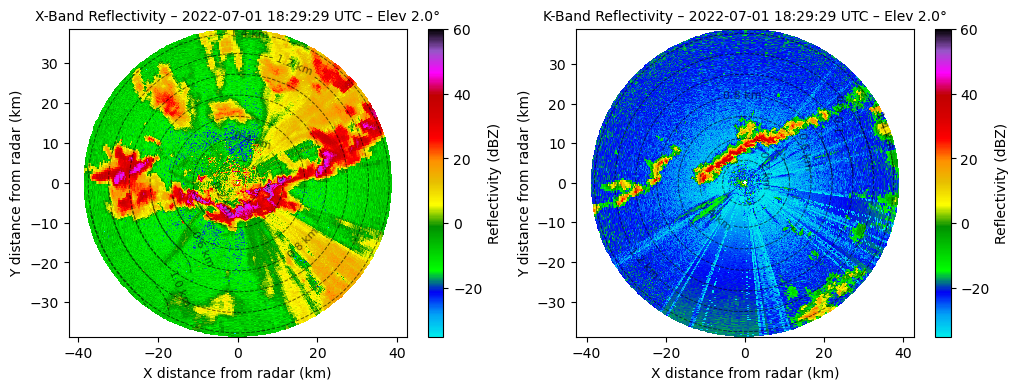

In [251]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
RadarData_XBand.PlotReflectivity(axis=axes[0])
RadarData_KBand.PlotReflectivity(axis=axes[1])

In [252]:
##########################
#GRIDDED RADAR DATA

In [255]:
# #LOADING DATA
# grid_XBand, data_XBand = RadarData_XBand.GridRadarReflectivity(radar_XBand)
# grid_KBand, data_KBand = RadarData_XBand.GridRadarReflectivity(radar_KBand)

In [256]:
# #PLOTTING DATA

# fig, axes = plt.subplots(1, 2, figsize=(12,4))
# RadarData_XBand.PlotGridReflectivity(grid_XBand,data_XBand, axis=axes[0])
# RadarData_KBand.PlotGridReflectivity(grid_KBand,data_KBand, axis=axes[1])